In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../data/raw/fashion_boutique_dataset.csv")

In [14]:
print(df.shape)
print("--h--")
print(df.head())
print("--t--")
print(df.tail())
print("--s--")
print(df.sample())
print("--c--")
print(df.columns)
print("--in--")
print(df.info())
print("--de--")
df.describe()


(2176, 14)
--h--
  product_id     category            brand  season size  color  \
0   FB000001    Outerwear             Zara  Spring   XL    Red   
1   FB000002         Tops           Uniqlo  Winter    L   Pink   
2   FB000003  Accessories           Uniqlo  Winter  NaN  Black   
3   FB000004        Shoes           Uniqlo  Spring   XL  Black   
4   FB000005         Tops  Banana Republic  Winter   XL  Black   

   original_price  markdown_percentage  current_price purchase_date  \
0          196.01                  0.0         196.01    2025-07-05   
1          119.64                  0.0         119.64    2025-08-06   
2           33.80                  0.0          33.80    2025-08-06   
3           75.36                  0.0          75.36    2025-07-07   
4          105.02                  0.0         105.02    2025-08-06   

   stock_quantity  customer_rating  is_returned return_reason  
0              37              3.0        False           NaN  
1               2              

,original_price,markdown_percentage,current_price,stock_quantity,customer_rating
count,2176.000000,2176.000000,2176.000000,2176.000000,1814.000000
mean,97.200340,12.144715,85.499596,24.937960,2.986604
std,51.637345,18.417786,50.091354,14.451387,1.159722
min,15.140000,0.000000,7.290000,0.000000,1.000000
25%,57.872500,0.000000,46.845000,13.000000,2.000000
50%,88.600000,0.000000,74.885000,25.000000,3.000000
75%,127.630000,22.425000,112.865000,37.000000,4.000000
max,249.980000,59.900000,249.980000,50.000000,5.000000


In [15]:
# Missing Values

missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": round(df.isnull().mean()*100,2)
})

missing_values.sort_values("Missing Values", ascending=False)

,Missing Values,Missing Percentage
return_reason,1856,85.29
size,491,22.56
customer_rating,362,16.64
brand,0,0.00
category,0,0.00
product_id,0,0.00
color,0,0.00
season,0,0.00
original_price,0,0.00
markdown_percentage,0,0.00


In [16]:
duplicate_rows = df.duplicated().sum()

print(f"Duplicate Rows : {duplicate_rows}")

Duplicate Rows : 0


In [17]:
duplicate_product_ids = df["product_id"].duplicated().sum()

print(f"Duplicate Product IDs : {duplicate_product_ids}")

Duplicate Product IDs : 0


In [18]:
print("Total Brands :", df["brand"].nunique())

df["brand"].unique()

Total Brands : 8


<StringArray>
[           'Zara',          'Uniqlo', 'Banana Republic',           'Mango',
             'H&M',      'Ann Taylor',             'Gap',       'Forever21']
Length: 8, dtype: str

In [19]:
print("Total Categories :", df["category"].nunique())

df["category"].unique()

Total Categories : 6


<StringArray>
['Outerwear', 'Tops', 'Accessories', 'Shoes', 'Bottoms', 'Dresses']
Length: 6, dtype: str

In [20]:
print("Total Seasons :", df["season"].nunique())

df["season"].unique()

Total Seasons : 4


<StringArray>
['Spring', 'Winter', 'Fall', 'Summer']
Length: 4, dtype: str

In [21]:
print("Total Colors :", df["color"].nunique())

df["color"].unique()

Total Colors : 11


<StringArray>
[   'Red',   'Pink',  'Black',  'White',   'Gray',   'Blue',  'Green',
  'Beige',   'Navy', 'Purple',  'Brown']
Length: 11, dtype: str

In [22]:
print("Total Sizes :", df["size"].nunique())

df["size"].unique()

Total Sizes : 6


<StringArray>
['XL', 'L', nan, 'S', 'XXL', 'XS', 'M']
Length: 7, dtype: str

In [23]:
df[["original_price","current_price"]].describe().round(2)

,original_price,current_price
count,2176.00,2176.00
mean,97.20,85.50
std,51.64,50.09
min,15.14,7.29
25%,57.87,46.84
50%,88.60,74.88
75%,127.63,112.86
max,249.98,249.98


In [24]:
df["markdown_percentage"].describe().round(2)

count    2176.00
mean       12.14
std        18.42
min         0.00
25%         0.00
50%         0.00
75%        22.42
max        59.90
Name: markdown_percentage, dtype: float64

In [25]:
df["customer_rating"].describe().round(2)

count    1814.00
mean        2.99
std         1.16
min         1.00
25%         2.00
50%         3.00
75%         4.00
max         5.00
Name: customer_rating, dtype: float64

In [26]:
df["stock_quantity"].describe().round(2)

count    2176.00
mean       24.94
std        14.45
min         0.00
25%        13.00
50%        25.00
75%        37.00
max        50.00
Name: stock_quantity, dtype: float64

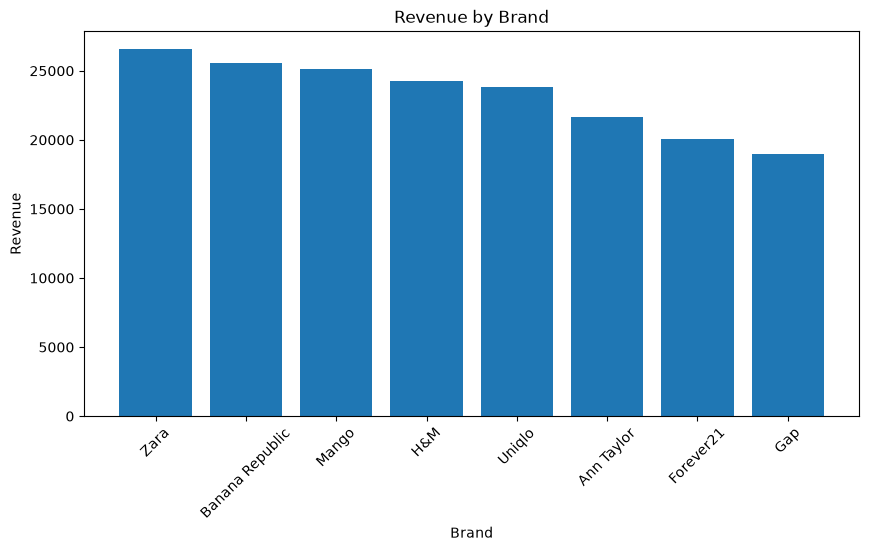

In [27]:
brand_revenue = (
    df.groupby("brand")["current_price"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

plt.bar(brand_revenue.index, brand_revenue.values)

plt.title("Revenue by Brand")
plt.xlabel("Brand")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

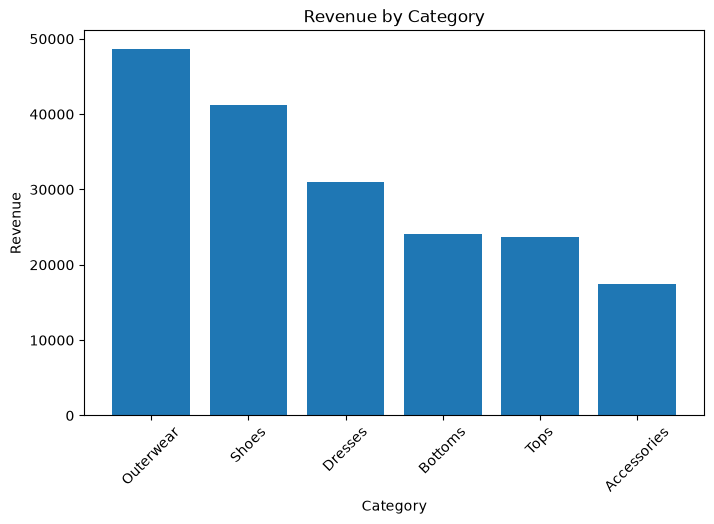

In [28]:
category_revenue = (
    df.groupby("category")["current_price"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

plt.bar(category_revenue.index, category_revenue.values)

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

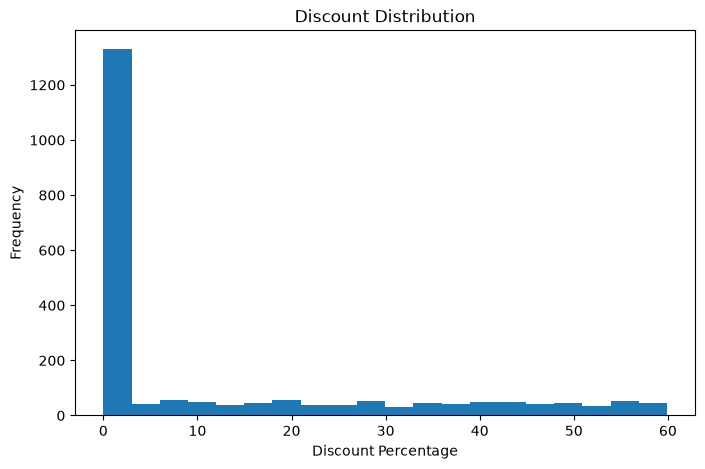

In [29]:
plt.figure(figsize=(8,5))

plt.hist(df["markdown_percentage"], bins=20)

plt.title("Discount Distribution")
plt.xlabel("Discount Percentage")
plt.ylabel("Frequency")

plt.show()

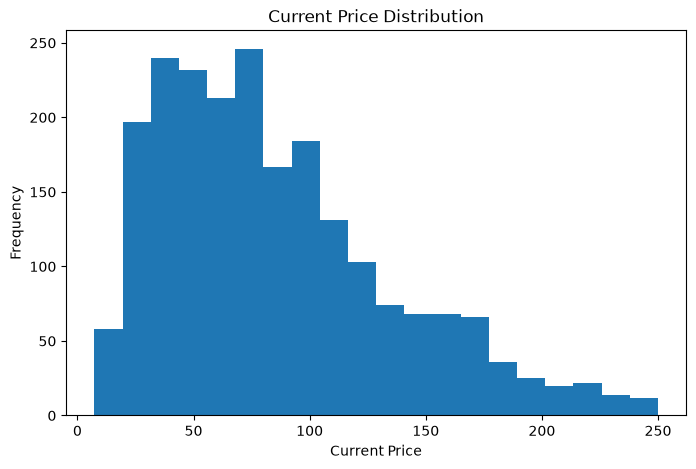

In [30]:
plt.figure(figsize=(8,5))

plt.hist(df["current_price"], bins=20)

plt.title("Current Price Distribution")
plt.xlabel("Current Price")
plt.ylabel("Frequency")

plt.show()

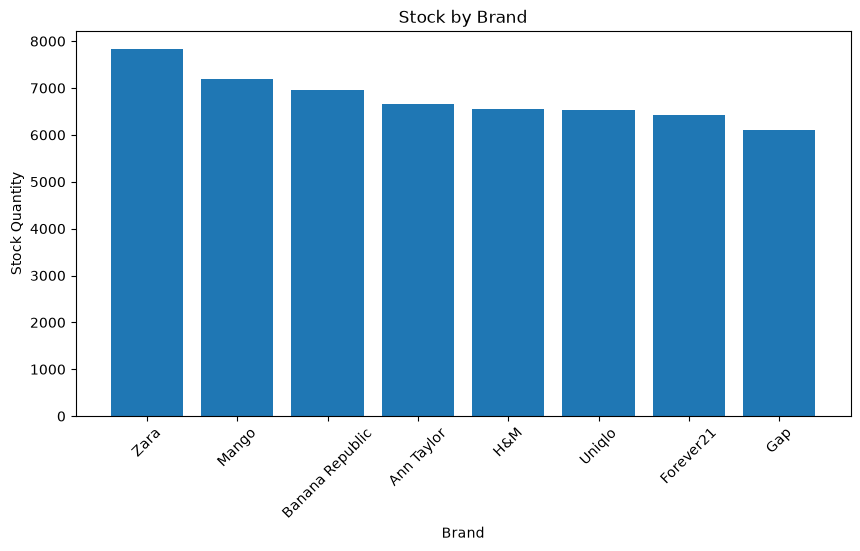

In [31]:
stock_brand = (
    df.groupby("brand")["stock_quantity"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

plt.bar(stock_brand.index, stock_brand.values)

plt.title("Stock by Brand")
plt.xlabel("Brand")
plt.ylabel("Stock Quantity")

plt.xticks(rotation=45)

plt.show()

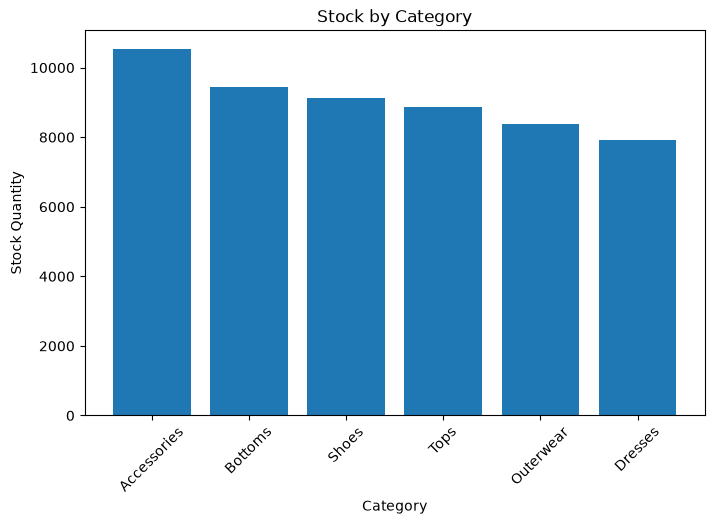

In [32]:
stock_category = (
    df.groupby("category")["stock_quantity"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

plt.bar(stock_category.index, stock_category.values)

plt.title("Stock by Category")
plt.xlabel("Category")
plt.ylabel("Stock Quantity")

plt.xticks(rotation=45)

plt.show()

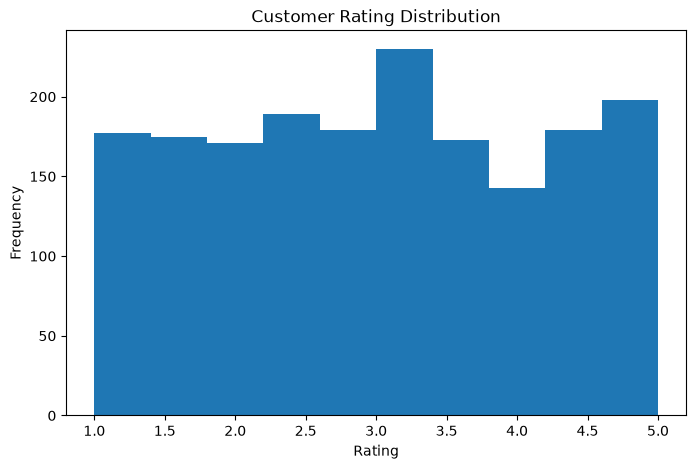

In [33]:
ratings = df["customer_rating"].dropna()

plt.figure(figsize=(8,5))

plt.hist(ratings, bins=10)

plt.title("Customer Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.show()

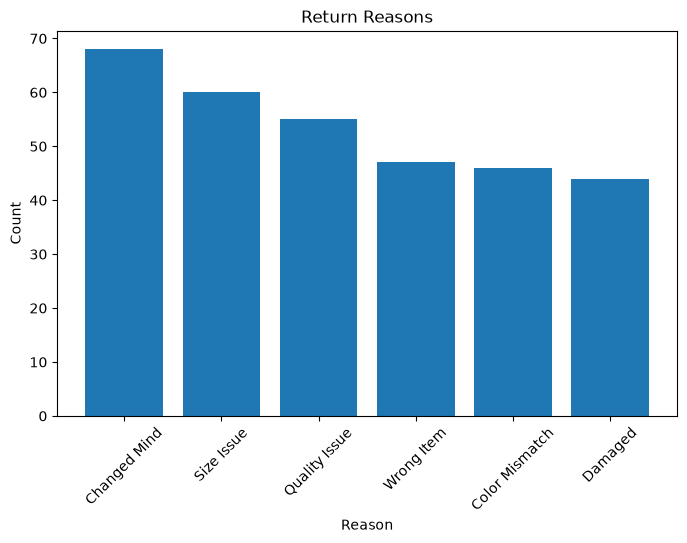

In [34]:
return_reason = (
    df[df["is_returned"]==True]
    ["return_reason"]
    .value_counts()
)

plt.figure(figsize=(8,5))

plt.bar(return_reason.index, return_reason.values)

plt.title("Return Reasons")
plt.xlabel("Reason")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

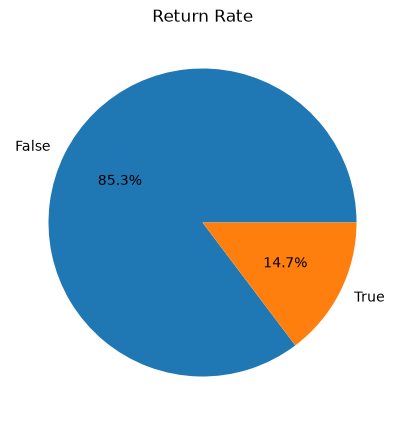

In [35]:
return_counts = df["is_returned"].value_counts()

plt.figure(figsize=(5,5))

plt.pie(
    return_counts,
    labels=return_counts.index,
    autopct="%1.1f%%"
)

plt.title("Return Rate")

plt.show()

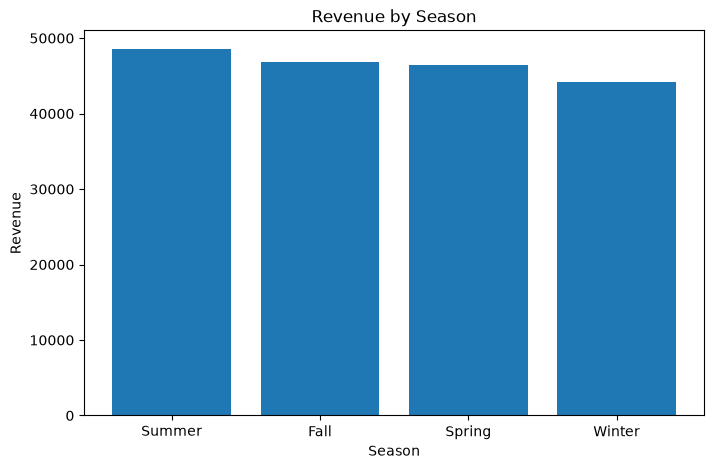

In [36]:
season_revenue = (
    df.groupby("season")["current_price"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

plt.bar(season_revenue.index, season_revenue.values)

plt.title("Revenue by Season")
plt.xlabel("Season")
plt.ylabel("Revenue")

plt.show()